In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from sklearn.metrics import roc_auc_score, average_precision_score
from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# ============================================================
# Parameters
# ============================================================

# Variant classes to evaluate. Set to None to run all available classes.
# Available: missense, missense_structured, missense_non_structured,
#            missense_disordered, missense_lip, intron,
#            enhancer_encode, promoter_encode, tf_encode,
#            proximal_promoter, core_promoter, all_variants, all_non_coding
selected_variant_classes = [
    'missense',
    'missense_structured',
    'missense_non_structured',
    'missense_lip',
    # 'intron',
    # 'enhancer_encode',
    # 'promoter_encode',
    # 'tf_encode',
    # 'all_variants',
]
# selected_variant_classes = None  # uncomment to run all

# ClinVar labels classified as Pathogenic
patho_labels = ['Pathogenic', 'Likely_pathogenic']

# ClinVar labels classified as Benign.
# If None, all variants NOT matching patho_labels are used as Benign.
benign_labels = ['Benign', 'Likely_benign']
# benign_labels = None  # uncomment to use all non-pathogenic as benign

LOCAL_ANNO_DIR = "/s/project/deeprvat/ukb_gym/variant_files"
variant_class_path = "config_variant_classes.yaml"
config_pheno_path = "config_pheno.yaml"

In [3]:
# Load variant class config
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

# Load annotation tool config and build dataframe
with open(config_pheno_path) as f:
    pheno_config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in pheno_config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df["annotation"].to_list()

print(f"Annotation categories: {anno_config_df['category'].unique().to_list()}")
print(f"Total annotations: {len(all_annotation_list)}")
anno_config_df

Annotation categories: ['3utr', 'genetic_diversity', 'naive', 'loftee_protein_domains', 'plof', 'regulatory', 'plof_consequences', '5utr', 'missense', 'conservation', 'encode_custom', 'encode_regions', 'protein_domains', 'regulatory_nondir', 'dubious_plof', 'vep_consequences', 'splicing']
Total annotations: 62


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [4]:
# Load ClinVar annotations (lazy), apply SNV filter, add derived columns
clinvar_anno = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/clinvar_variants_annotations_with_all.parquet")
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        (pl.col('ref').str.len_chars() == 1) & (pl.col('alt').str.len_chars() == 1)
    )
    .with_columns(
        promoterai_under=pl.col('promoterai'),
        promoterai_abs=pl.col('promoterai').abs(),
    )
)

schema_cols = clinvar_anno.collect_schema().names()
available_annos = [c for c in all_annotation_list if c in schema_cols]
print(f"Total columns: {len(schema_cols)}")
print(f"Available annotation columns: {len(available_annos)} / {len(all_annotation_list)}")
print(f"Unique clinical_significance values:")
clinvar_anno.select('clinical_significance').collect()['clinical_significance'].value_counts(sort=True)

Total columns: 203
Available annotation columns: 49 / 62
Unique clinical_significance values:


clinical_significance,count
str,u64
"""Uncertain_significance""",1000371
"""Likely_benign""",292172
null,103397
"""Benign""",54812
"""Conflicting_classifications_of…",32710
…,…
"""Uncertain_significance|Affects""",2
"""Pathogenic|Affects""",2
"""Conflicting_classifications_of…",1


In [5]:
def label_matches(series: pl.Series, labels: list) -> pl.Series:
    """Return boolean mask: True if clinical_significance contains any of the given labels.
    Handles compound values like 'Benign/Likely_benign'."""
    mask = pl.Series([False] * len(series))
    for lbl in labels:
        mask = mask | series.str.contains(lbl, literal=True).fill_null(False)
    return mask


def compute_metrics_for_class(
    vc_name: str,
    vc_config: dict,
    clinvar_anno: pl.LazyFrame,
    anno_config_df: pl.DataFrame,
    patho_labels: list,
    benign_labels,
) -> pl.DataFrame | None:
    vc_filters = vc_config.get('variant_filtering') or []
    tool_categories = vc_config.get('tool_categories', [])
    x_label = vc_config.get('x_label', vc_name)

    # Annotation tools for this variant category
    selected_annos_cfg = anno_config_df.filter(pl.col('category').is_in(tool_categories))
    anno_cols_in_schema = [
        c for c in selected_annos_cfg['annotation'].to_list()
        if c in clinvar_anno.collect_schema().names()
    ]

    if not anno_cols_in_schema:
        print(f"  {vc_name}: no annotation columns available, skipping")
        return None

    # Build and apply variant-class filters
    _dynamic_filters = [eval(f) for f in vc_filters] if vc_filters else []
    try:
        df = (
            clinvar_anno
            .filter(*_dynamic_filters)
            .select(['id', 'clinical_significance'] + anno_cols_in_schema)
            .collect()
        )
    except Exception as e:
        print(f"  {vc_name}: error loading — {e}")
        return None

    clin_sig = df['clinical_significance'].fill_null('')

    # Build pathogenic / benign masks
    patho_mask = label_matches(clin_sig, patho_labels)

    if benign_labels is None:
        benign_mask = ~patho_mask
    else:
        benign_mask = label_matches(clin_sig, benign_labels)

    df = df.with_columns(
        is_patho=patho_mask.cast(pl.Int8),
        is_benign=benign_mask.cast(pl.Int8),
    ).filter(patho_mask | benign_mask)

    n_patho = int(df['is_patho'].sum())
    n_benign = int(df['is_benign'].sum())

    if n_patho == 0 or n_benign == 0:
        print(f"  {vc_name}: n_patho={n_patho}, n_benign={n_benign} — skipping")
        return None

    print(f"  {vc_name}: {n_patho} pathogenic, {n_benign} benign, total={df.shape[0]}")

    results = []
    for row in selected_annos_cfg.iter_rows(named=True):
        anno = row['annotation']
        if anno not in df.columns:
            continue

        anno_dir = row['annotation_dir']
        sub = df.select(['is_patho', anno]).drop_nulls()
        if sub.shape[0] < 10:
            continue

        y_true = sub['is_patho'].to_numpy()
        y_score = sub[anno].to_numpy().astype(float) * anno_dir

        if y_true.sum() == 0 or y_true.sum() == len(y_true):
            continue

        try:
            auroc = float(roc_auc_score(y_true, y_score))
            auprc = float(average_precision_score(y_true, y_score))
        except Exception:
            continue

        results.append({
            'variant_class': vc_name,
            'x_label': x_label,
            'annotation': anno,
            'label': row['label'],
            'color': row['color'],
            'auroc': auroc,
            'auprc': auprc,
            'n_patho': n_patho,
            'n_benign': n_benign,
        })

    return pl.DataFrame(results) if results else None

In [6]:
# Run for all (or selected) variant classes
vc_names = selected_variant_classes or list(variant_class_config.keys())

all_results = []
for vc_name in vc_names:
    vc_config = variant_class_config[vc_name]
    print(f"Processing: {vc_name}")
    result = compute_metrics_for_class(
        vc_name, vc_config, clinvar_anno, anno_config_df, patho_labels, benign_labels
    )
    if result is not None:
        all_results.append(result)

results_df = pl.concat(all_results) if all_results else pl.DataFrame()
print(f"\nTotal: {results_df.shape[0]} rows across {results_df['variant_class'].n_unique()} variant classes")
results_df

Processing: missense
  missense: 9381 pathogenic, 45594 benign, total=54975
Processing: missense_structured
  missense_structured: 6653 pathogenic, 14800 benign, total=21453
Processing: missense_non_structured
  missense_non_structured: 2728 pathogenic, 30794 benign, total=33522
Processing: missense_lip
  missense_lip: 1120 pathogenic, 12567 benign, total=13687

Total: 52 rows across 4 variant classes


variant_class,x_label,annotation,label,color,auroc,auprc,n_patho,n_benign
str,str,str,str,str,f64,f64,i64,i64
"""missense""","""Missense""","""am_pathogenicity""","""AlphaMissense""","""#feb72d""",0.91093,0.841864,9381,45594
"""missense""","""Missense""","""esmscoremissense""","""ESM1v""","""#feb72d""",0.908561,0.800736,9381,45594
"""missense""","""Missense""","""esm1b_llr""","""ESM1b""","""#feb72d""",0.633307,0.514315,9381,45594
"""missense""","""Missense""","""cpt1_llr""","""CPT-1""","""#feb72d""",0.896559,0.832789,9381,45594
"""missense""","""Missense""","""revel_score""","""REVEL""","""#feb72d""",0.895816,0.830993,9381,45594
…,…,…,…,…,…,…,…,…
"""missense_lip""","""LIP domain (missense)""","""verphylop""","""Vertebrate PhyloP""","""#942C80""",0.89811,0.455053,1120,12567
"""missense_lip""","""LIP domain (missense)""","""zooverphylop""","""Zoonomia Vertebrate PhyloP""","""#942C80""",0.865923,0.301503,1120,12567
"""missense_lip""","""LIP domain (missense)""","""mamphylop""","""Mammalian PhyloP""","""#942C80""",0.869131,0.28464,1120,12567


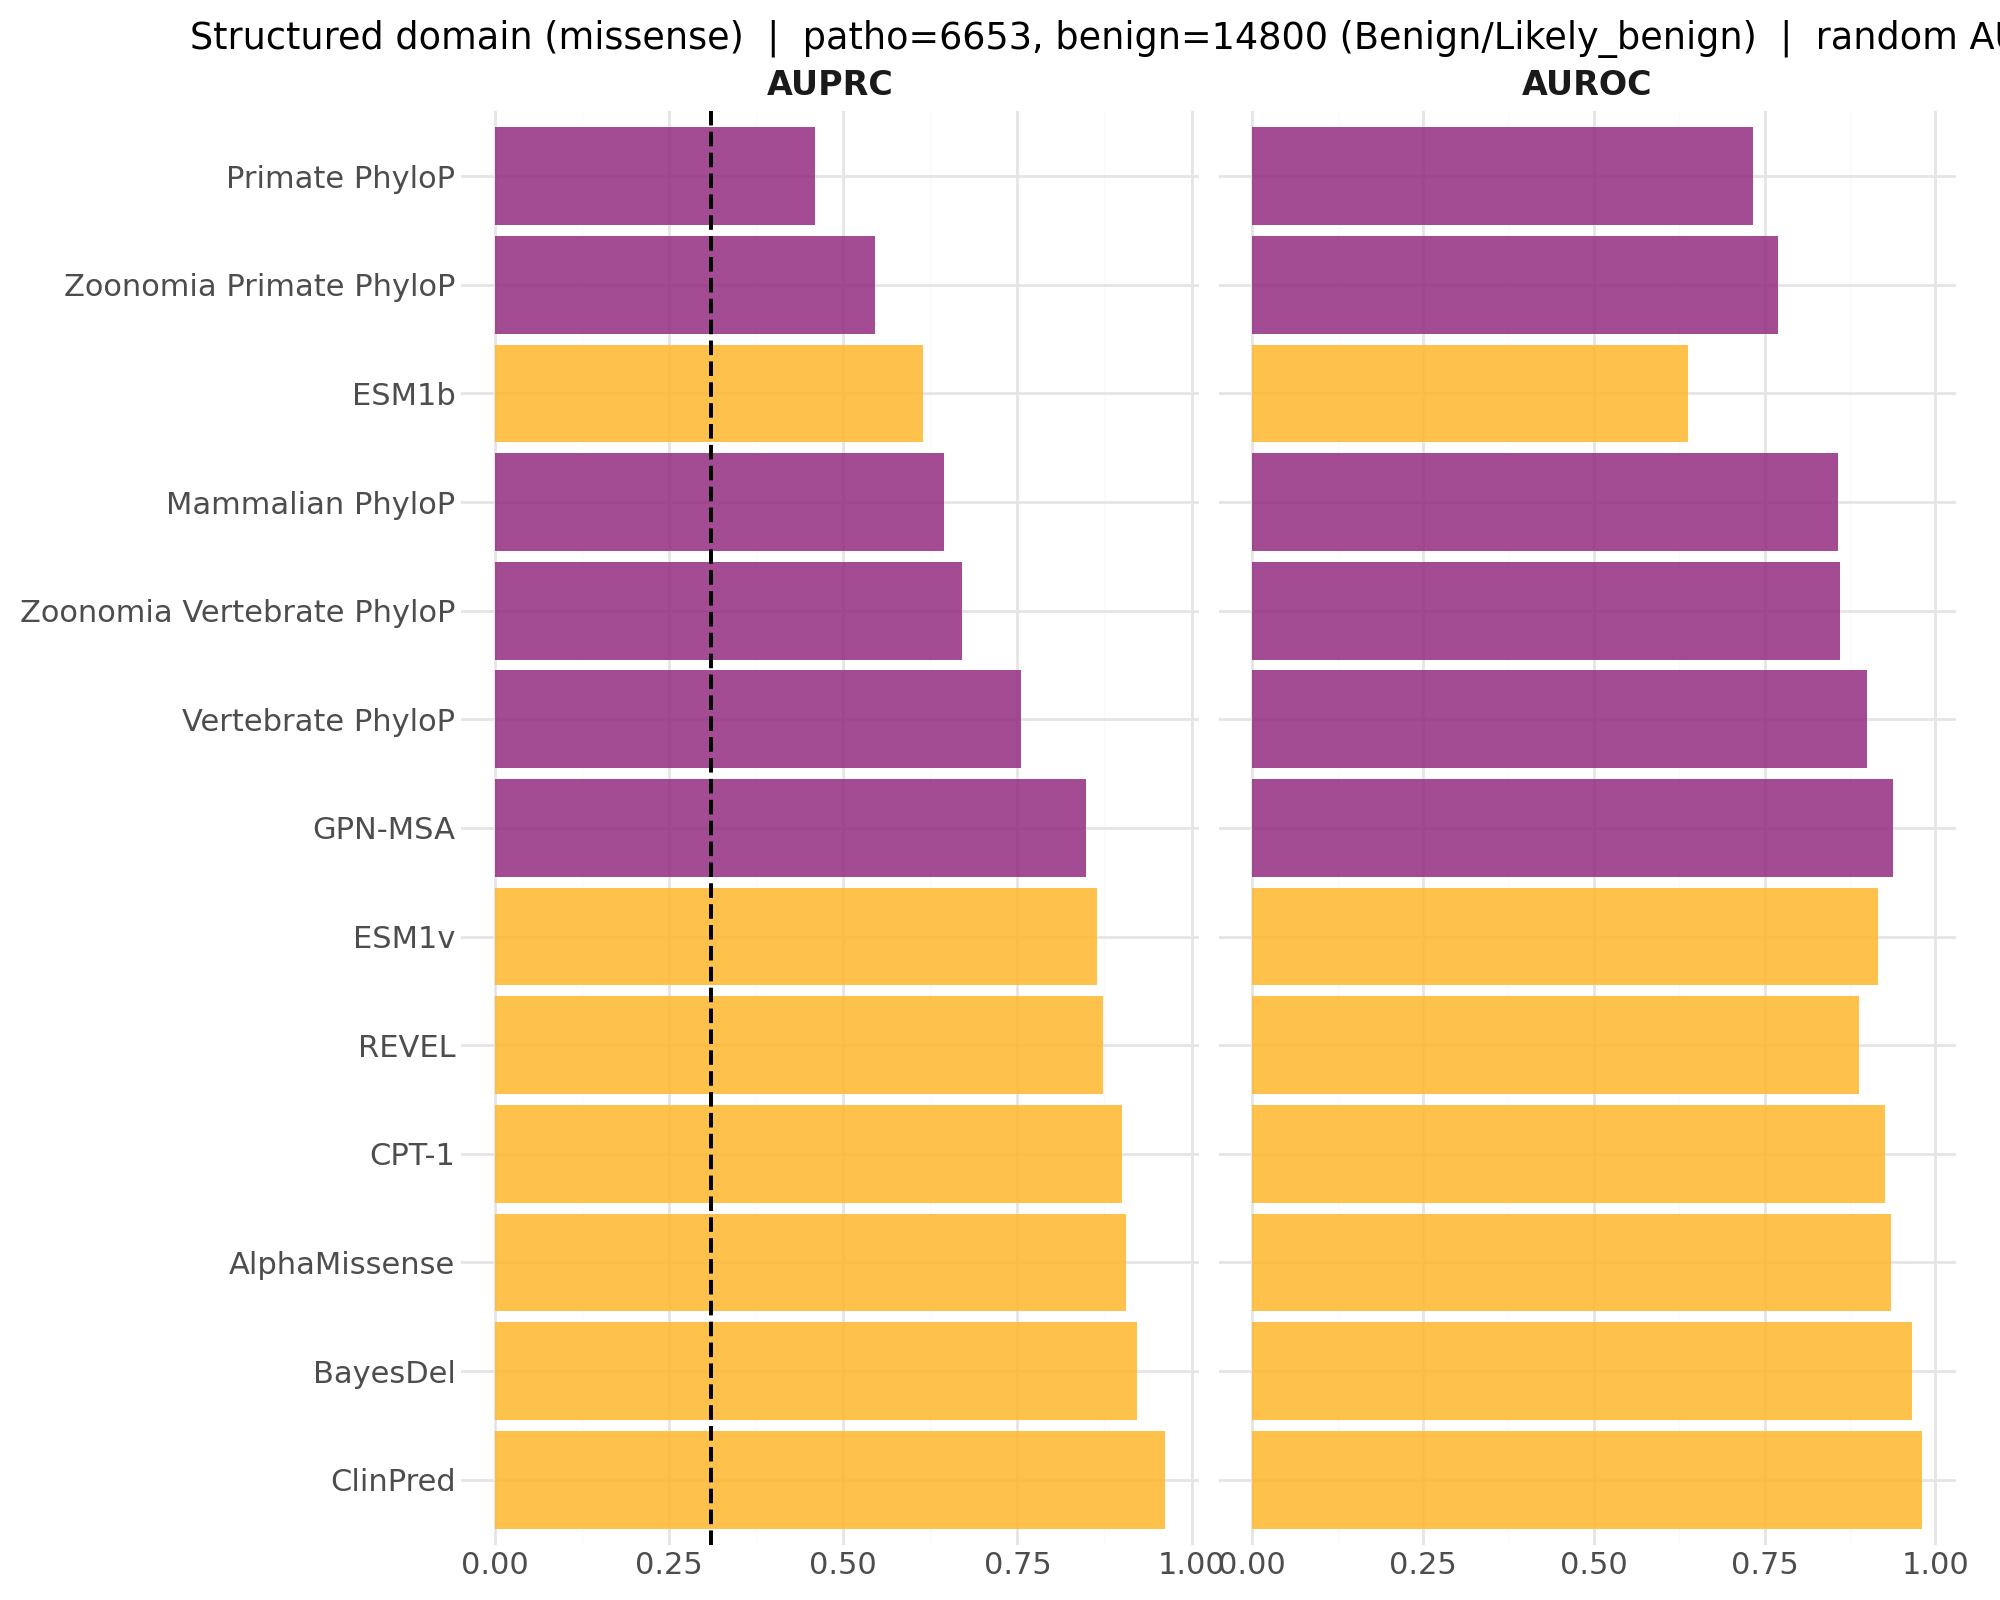

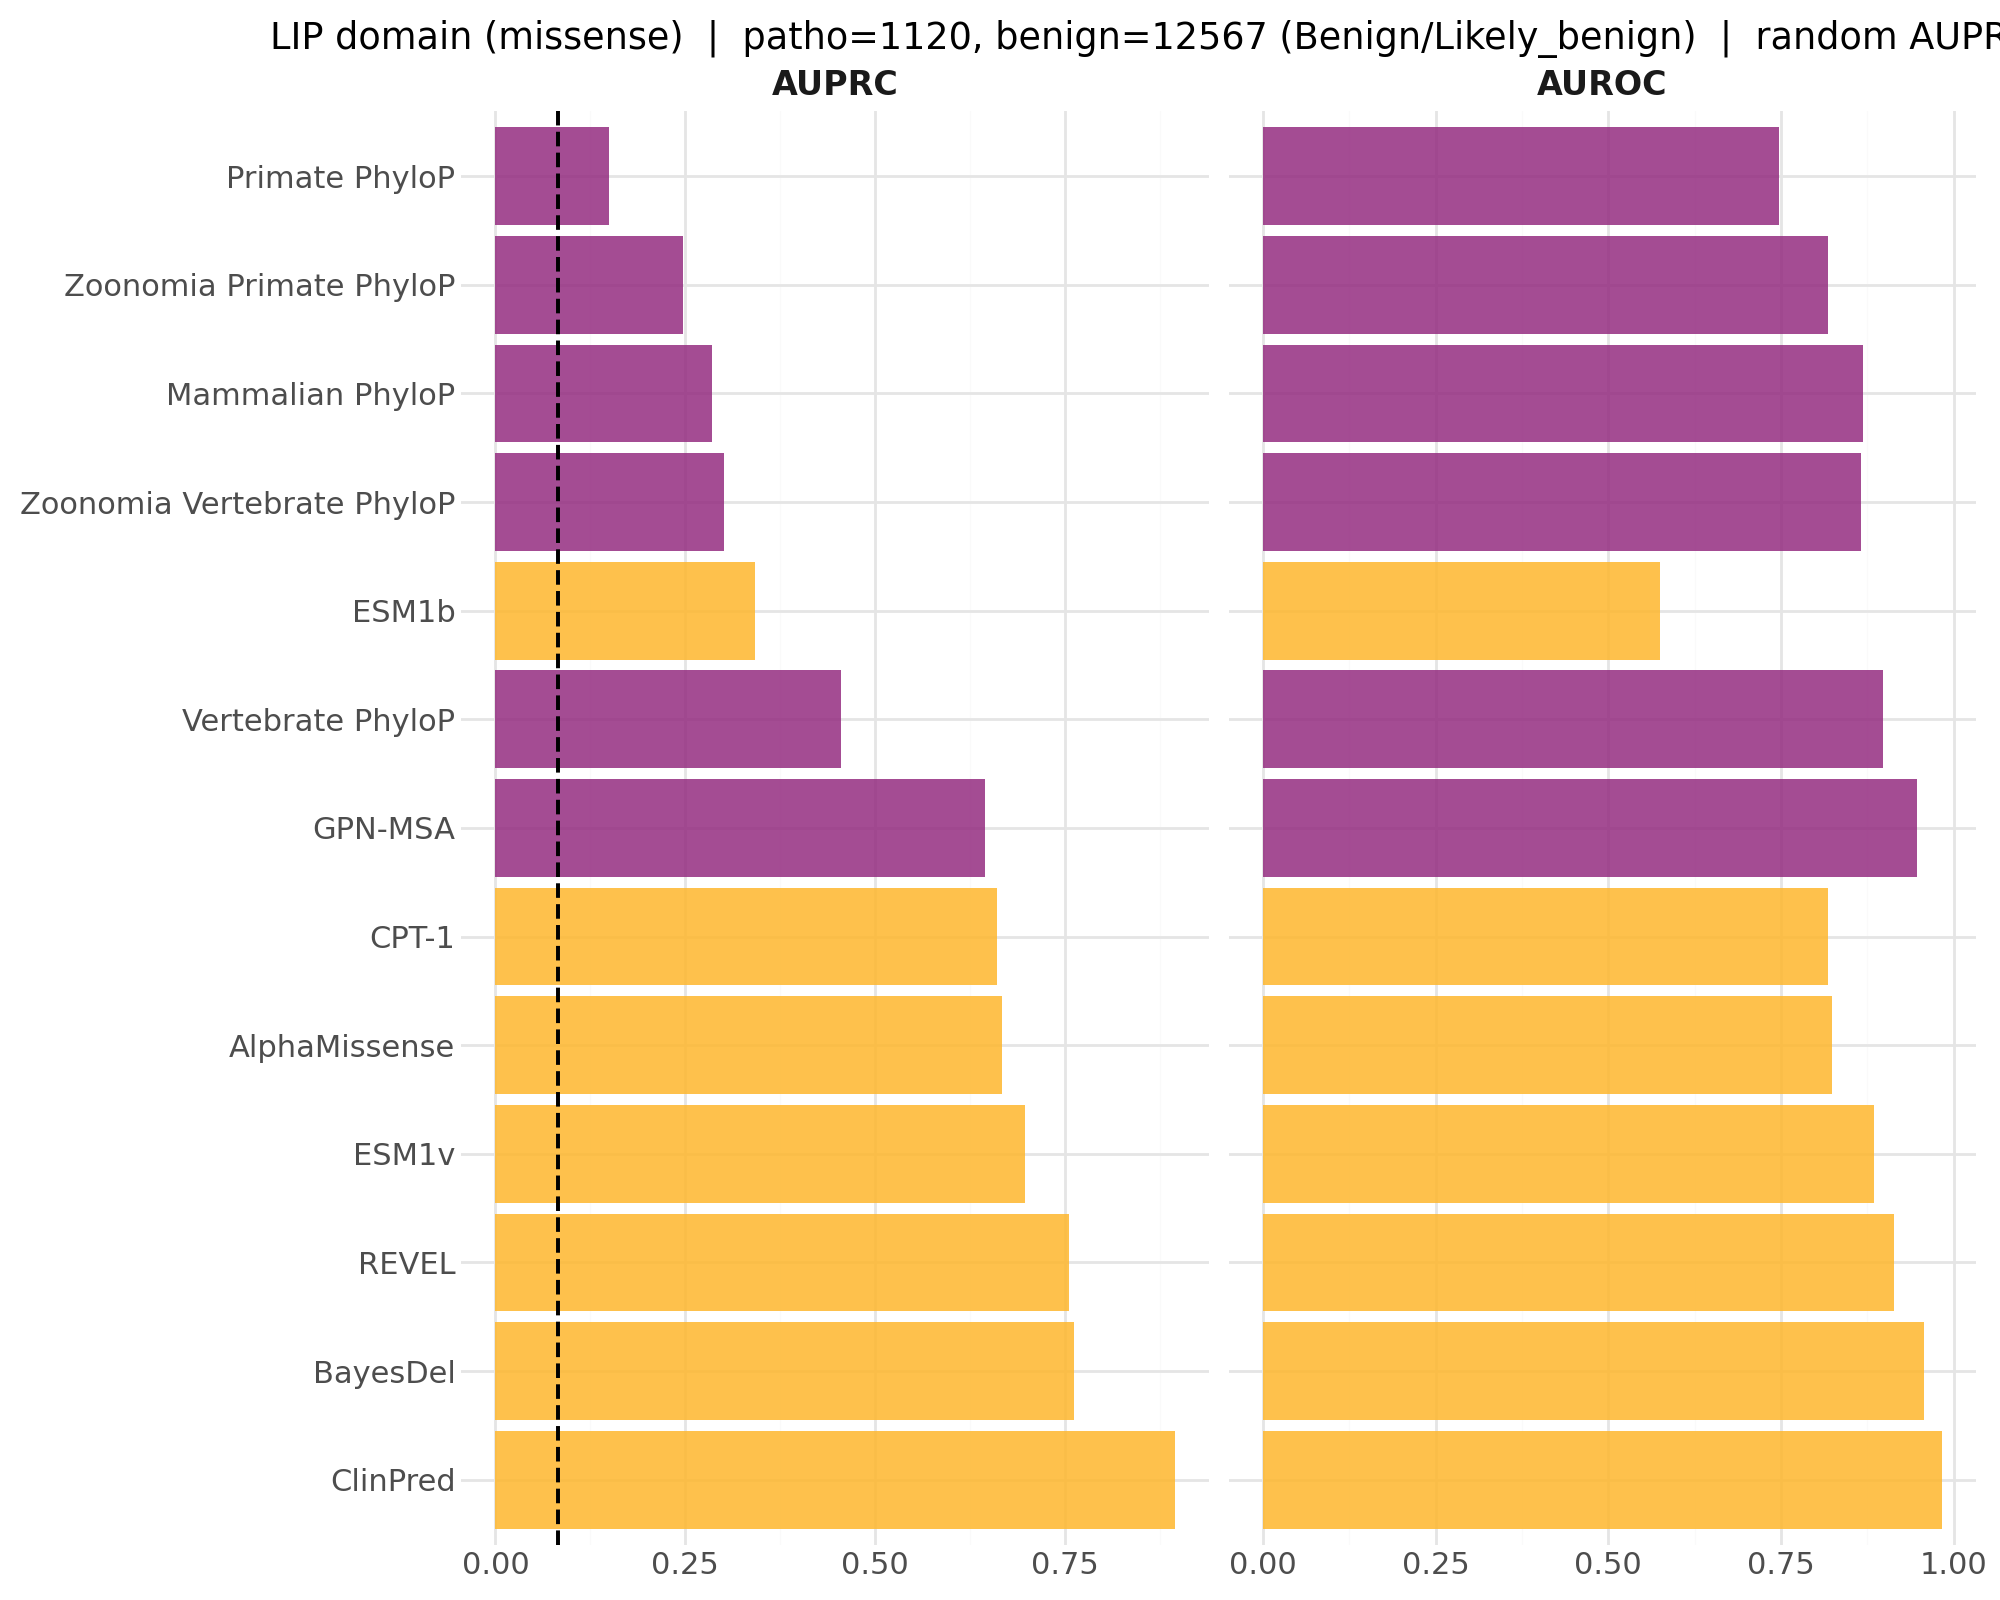

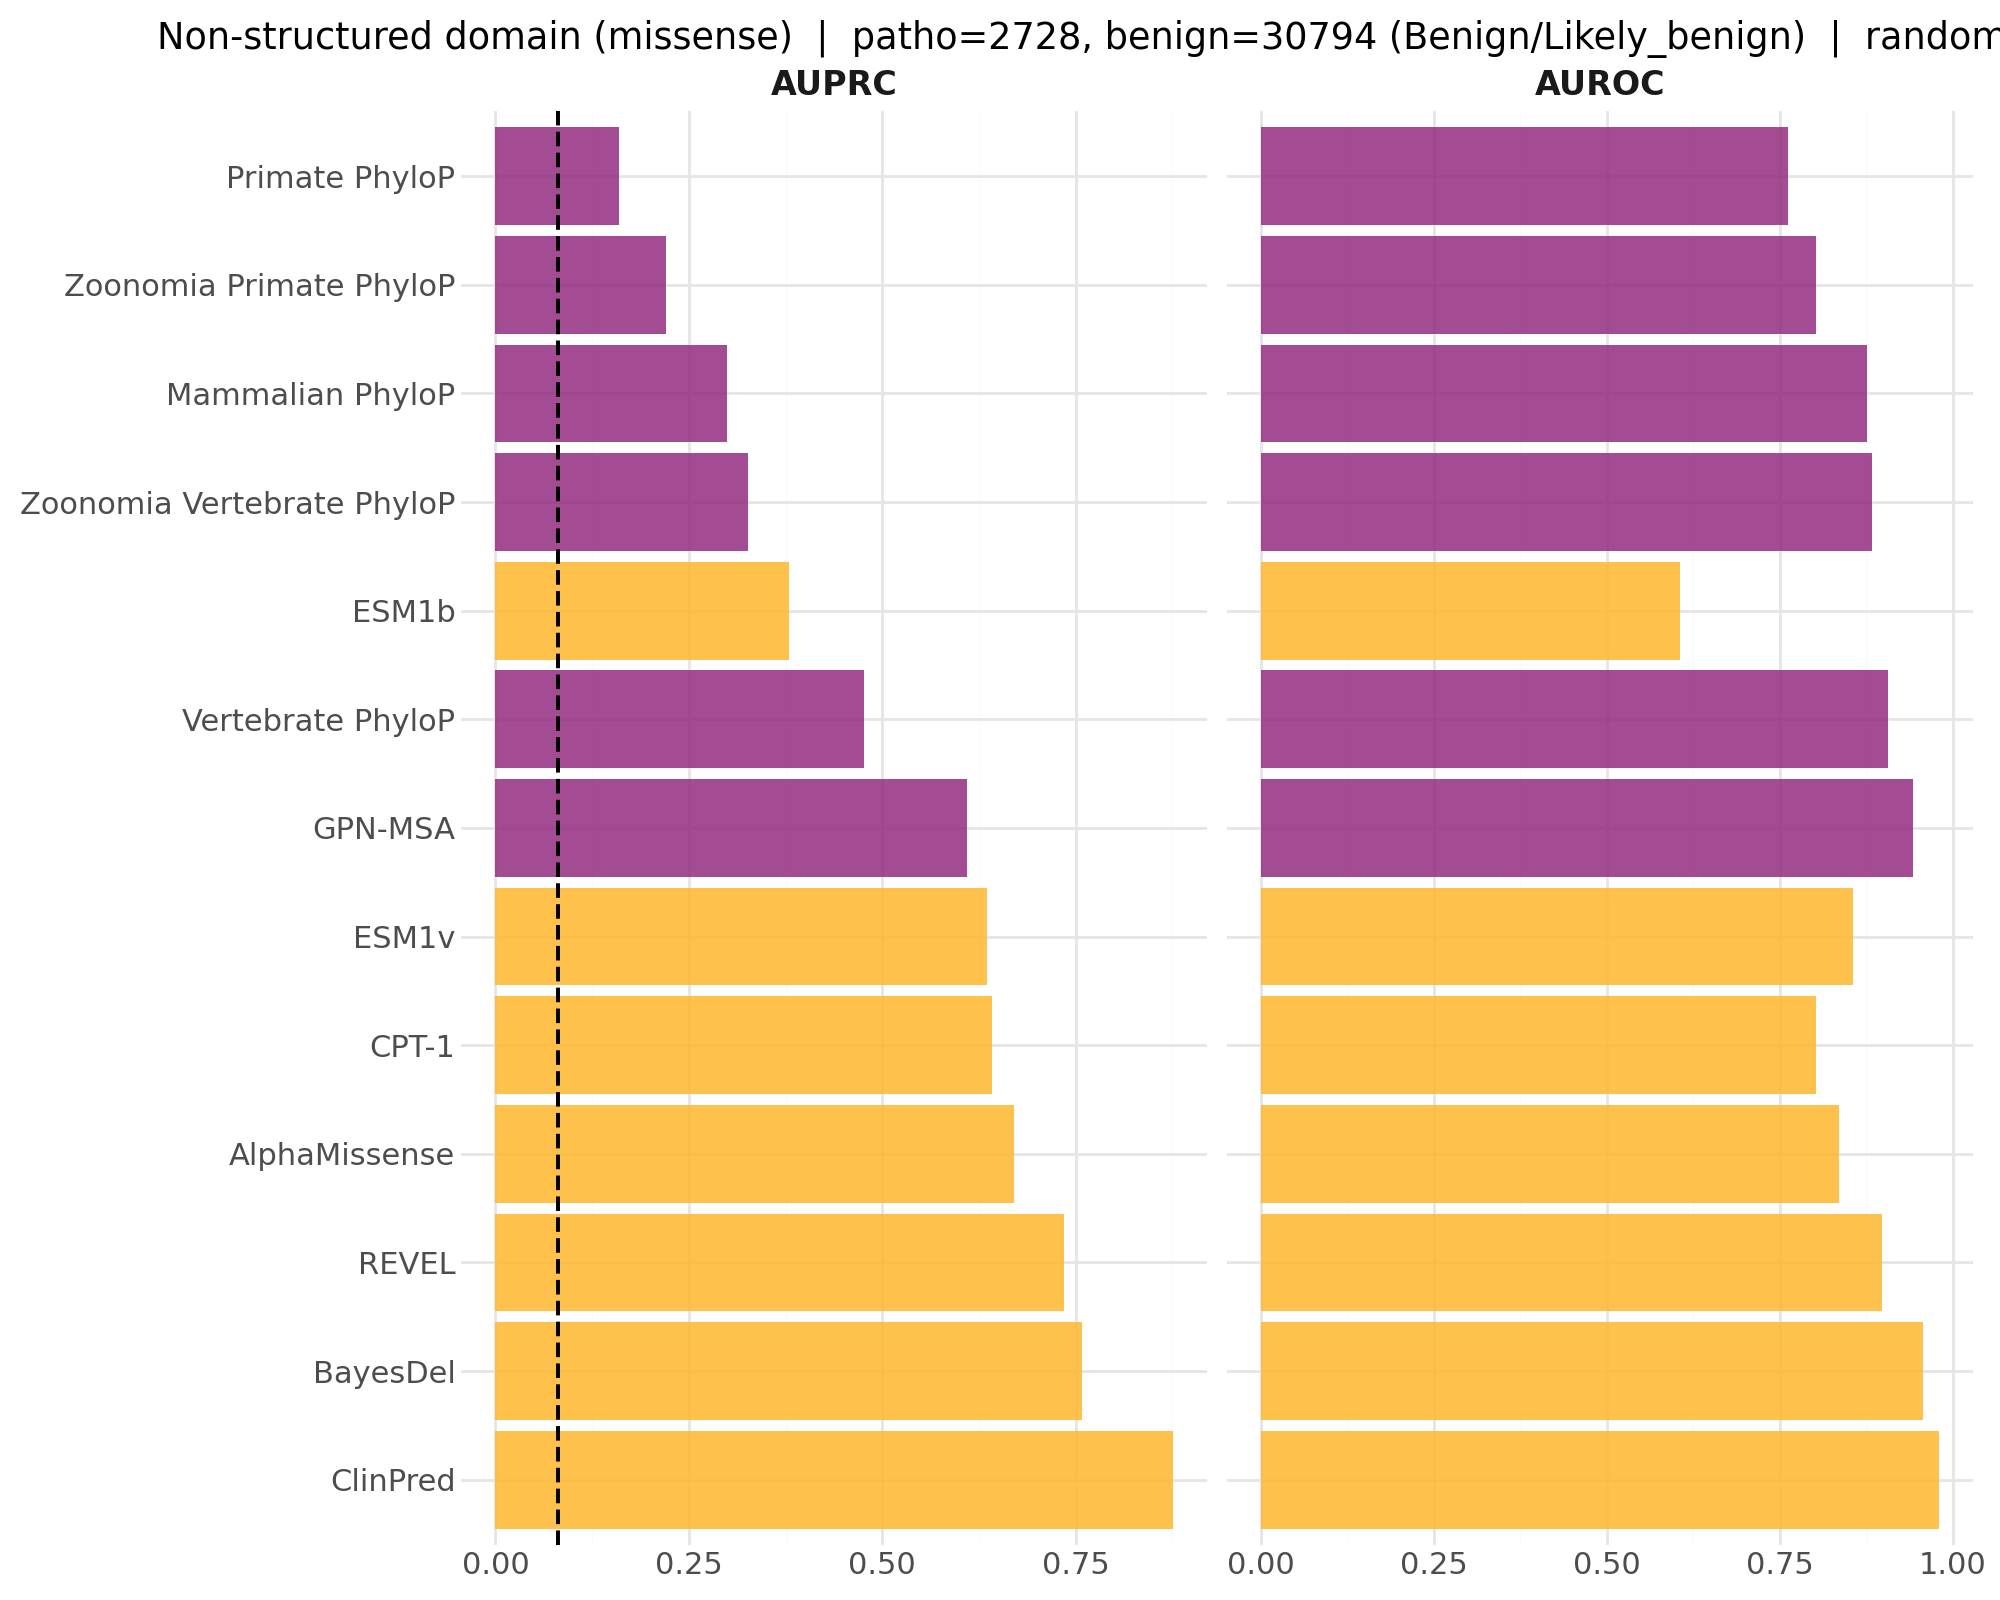

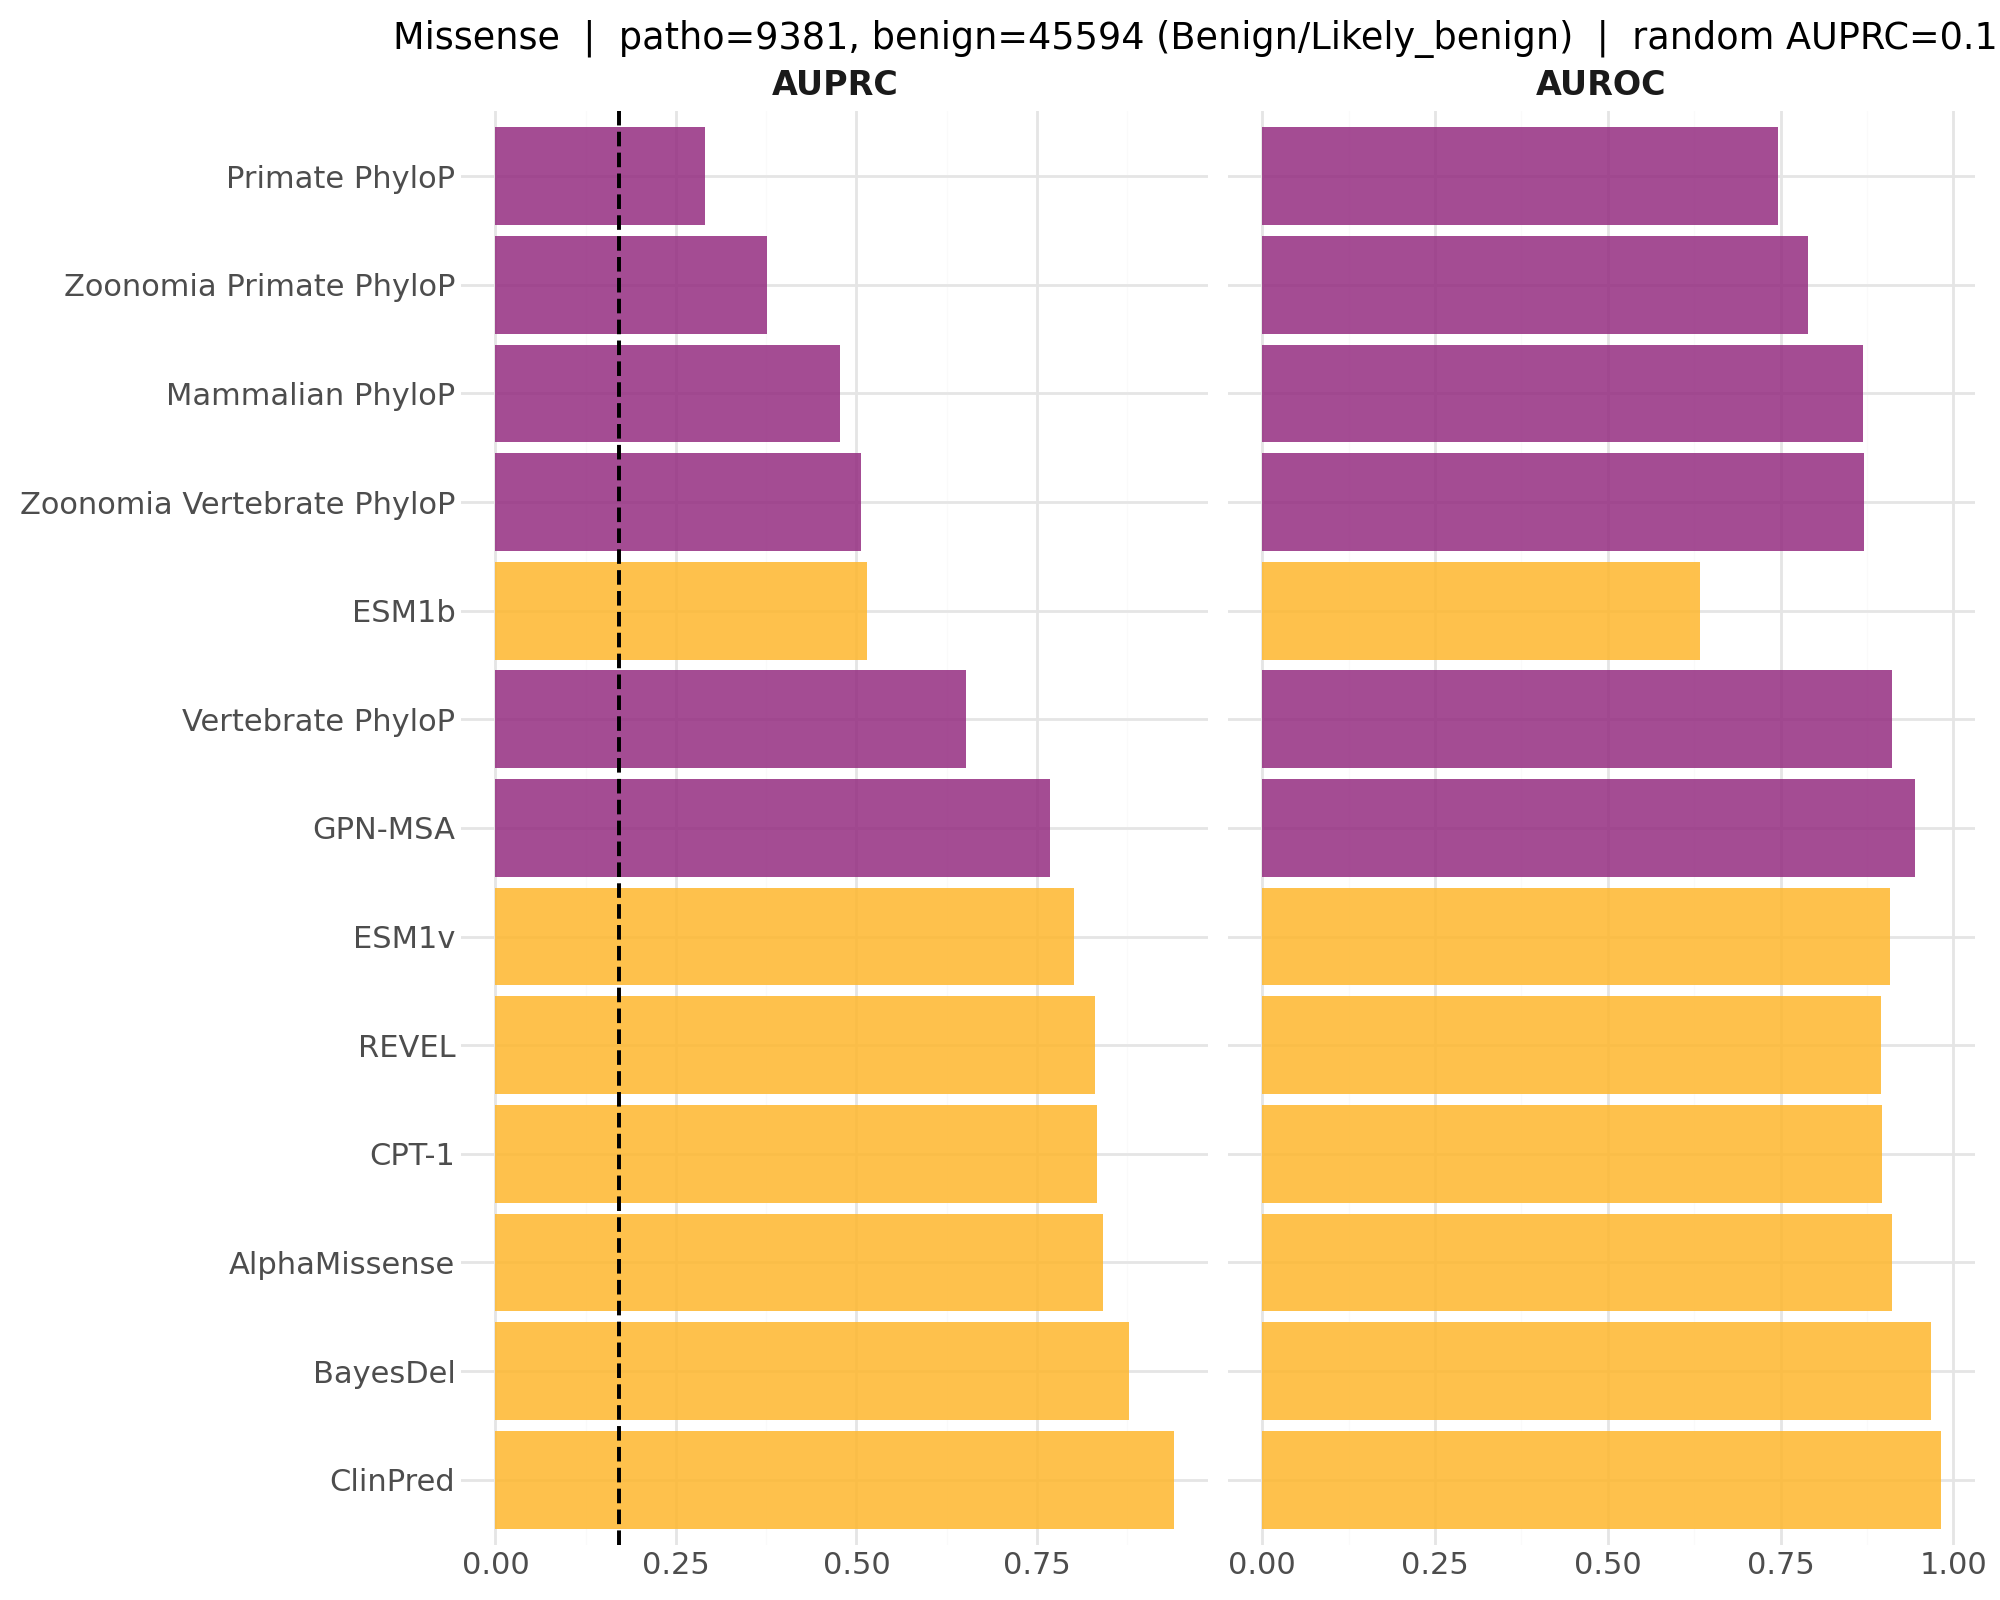

In [7]:
# One plot per variant category — AUROC and AUPRC side by side
benign_desc = 'all non-pathogenic' if benign_labels is None else '/'.join(benign_labels)

for vc_name in results_df['variant_class'].unique().to_list():
    vc_results = results_df.filter(pl.col('variant_class') == vc_name)
    x_label = vc_results['x_label'][0]
    n_patho = vc_results['n_patho'][0]
    n_benign = vc_results['n_benign'][0]
    random_baseline = n_patho / (n_patho + n_benign)

    # Order tools by AUPRC descending
    auprc_order = (
        vc_results
        .sort('auprc', descending=True)
        ['label']
        .to_list()
    )

    # Melt to long format for faceting AUROC / AUPRC
    plot_df = (
        vc_results
        .unpivot(
            index=['annotation', 'label', 'color'],
            on=['auroc', 'auprc'],
            variable_name='metric',
            value_name='value',
        )
        .with_columns(
            metric=pl.col('metric').replace({'auroc': 'AUROC', 'auprc': 'AUPRC'}),
            label=pl.col('label').cast(pl.Enum(auprc_order)),
        )
    )

    color_dict = dict(vc_results.select(['annotation', 'color']).unique().iter_rows())

    # Reference line only in the AUPRC facet
    ref_df = pl.DataFrame({'metric': ['AUPRC'], 'xintercept': [random_baseline]})

    p = (
        ggplot(plot_df, aes(x='label', y='value', fill='annotation'))
        + geom_col(alpha=0.85)
        + geom_hline(ref_df, aes(yintercept='xintercept'), linetype='dashed', color='black', size=0.8)
        + facet_wrap('~metric', scales='free_x')
        + coord_flip()
        + theme_minimal()
        + scale_fill_manual(values=color_dict)
        + labs(
            x='',
            y='',
            title=f"{x_label}  |  patho={n_patho}, benign={n_benign} ({benign_desc})  |  random AUPRC={random_baseline:.3f}",
        )
        + theme(
            figure_size=(10, len(auprc_order) / 2 + 1.5),
            legend_position='none',
            axis_text=element_text(size=11),
            axis_title=element_text(size=12),
            strip_text=element_text(size=12, face='bold'),
            plot_background=element_rect(fill='white', color='white'),
        )
    )
    p.show()